# A Decision Support Framework for Adaptive Inventory Replenishment Using Machine Learning-Based Demand Shock Prediction

This notebook implements the full research pipeline described in the dissertation:

1. Data loading, cleaning and weekly SKU-level aggregation
2. Demand-shock labelling via a rolling z-score
3. Supervised classification of shock severity (Random Forest vs XGBoost vs LightGBM)
4. Translation of predicted severity into an adaptive replenishment policy
5. Simulation of the adaptive policy against a static (s,S) baseline
6. Evaluation on both forecasting/classification metrics and inventory performance metrics
7. Statistical significance testing (Wilcoxon signed-rank test)

**Dataset:** Online Retail (Chen, Sain and Guo, 2012), UCI Machine Learning Repository — a single UK-based online retailer's transaction log, 1 December 2010 to 9 December 2011 (541,909 transaction records).

## 1. Research Aim, Objectives and Questions

**Aim:** To develop and evaluate a decision support framework that integrates machine learning-based demand shock prediction with adaptive inventory replenishment strategies to improve inventory performance under demand uncertainty.

**Objectives:**
1. Develop a machine learning model for predicting demand shock severity from historical sales and adapt it to a generated replenishment plan.
2. Compare Random Forest, XGBoost, and LightGBM in predicting demand shock severity, using classification performance metrics.
3. Design an adaptive inventory replenishment policy that maps predicted shock severity to safety stock / order-up-to adjustments.

**Research Questions:**
1. Which machine learning model (Random Forest, XGBoost, or LightGBM) predicts demand shock severity most accurately?
2. Can predicted shock severity be systematically translated into adaptive replenishment decisions?
3. What is the impact of the adaptive framework on inventory costs, stockout rate, and service level, relative to a static replenishment baseline?

## 1. Environment Setup

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import TimeSeriesSplit, GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, f1_score, precision_recall_fscore_support, classification_report,
                              confusion_matrix, mean_squared_error, mean_absolute_error)
import xgboost as xgb
import lightgbm as lgb
from scipy.stats import wilcoxon

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 5)
pd.set_option('display.max_columns', None)

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

## 2. Data Loading

In [2]:
DATA_PATH = '/content/Online Retail.xlsx'  # place the UCI Online Retail file alongside this notebook
raw = pd.read_excel(DATA_PATH)
print(f"Raw shape: {raw.shape}")
raw.head()

Raw shape: (541909, 8)


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [3]:
print(raw.dtypes)
print("\nMissing values:\n", raw.isna().sum())
print(f"\nDate range: {raw['InvoiceDate'].min()}  to  {raw['InvoiceDate'].max()}")
print(f"Unique StockCodes: {raw['StockCode'].nunique()}")
print(f"Unique Countries: {raw['Country'].nunique()}")

InvoiceNo              object
StockCode              object
Description            object
Quantity                int64
InvoiceDate    datetime64[ns]
UnitPrice             float64
CustomerID            float64
Country                object
dtype: object

Missing values:
 InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

Date range: 2010-12-01 08:26:00  to  2011-12-09 12:50:00
Unique StockCodes: 4070
Unique Countries: 38


## 3. Data Cleaning

In [4]:
df = raw.copy()
n0 = len(df)
summary = [("Raw dataset", "-", n0)]

# Step 1: Remove cancelled orders
before = len(df)
df = df[~df['InvoiceNo'].astype(str).str.startswith('C')]
removed = before - len(df)
summary.append(("Remove cancelled orders (InvoiceNo prefix 'C')", removed, len(df)))

# Step 2: Remove non-product administrative stock codes
admin_codes = ['POST', 'D', 'DOT', 'M', 'm', 'S', 'AMAZONFEE',
               'DCGSSBOY', 'DCGSSGIRL', 'PADS', 'B', 'CRUK']
before = len(df)
df = df[~df['StockCode'].astype(str).isin(admin_codes)]
removed = before - len(df)
summary.append(("Remove non-product stock codes (postage, fees, etc.)", removed, len(df)))

# Step 3: Remove non-positive quantity / price
before = len(df)
df = df[(df['Quantity'] > 0) & (df['UnitPrice'] > 0)]
removed = before - len(df)
summary.append(("Remove non-positive quantity / unit price rows", removed, len(df)))

# Step 4: Drop rows with missing description
before = len(df)
df = df.dropna(subset=['Description'])
removed = before - len(df)
summary.append(("Remove missing description", removed, len(df)))

# Build summary table
summary_df = pd.DataFrame(summary, columns=["Cleaning step", "Rows removed", "Rows remaining"])
print(summary_df.to_string(index=False))
print()
print(f"Total rows removed: {n0 - len(df):,} ({(n0 - len(df)) / n0:.1%})")
print(f"Final cleaned shape: {df.shape}")
print(f"Unique SKUs remaining (nunique on StockCode): {df['StockCode'].nunique():,}")

                                       Cleaning step Rows removed  Rows remaining
                                         Raw dataset            -          541909
      Remove cancelled orders (InvoiceNo prefix 'C')         9288          532621
Remove non-product stock codes (postage, fees, etc.)         2202          530419
      Remove non-positive quantity / unit price rows         2501          527918
                          Remove missing description            0          527918

Total rows removed: 13,991 (2.6%)
Final cleaned shape: (527918, 8)
Unique SKUs remaining (nunique on StockCode): 3,912


## 4. Weekly SKU-Level Aggregation

The dataset has no store or product-category dimension, so modelling operates at **SKU × week** granularity across a single retailer.

The 54-week observation window (29 Nov 2010 - 9 Dec 2011), anchored to a Monday so that each week genuinely runs Monday-Sunday, is built from `InvoiceDate`. Given the sparsity of individual SKU-level weekly transactions, modelling is restricted to **SKUs active in at least 30 of the 54 weeks**, to ensure sufficient signal density for reliable model training.


In [5]:
start_date = pd.Timestamp('2010-11-29')  # Monday-anchored, so weekly aggregation genuinely starts Monday
df['WeekIndex'] = ((df['InvoiceDate'] - start_date).dt.days // 7).astype(int)
N_WEEKS = df['WeekIndex'].max() + 1
print(f"Observation window: {N_WEEKS} weeks")

# Aggregate quantity sold per SKU per week
weekly = df.groupby(['StockCode', 'WeekIndex'])['Quantity'].sum().reset_index()
weekly.rename(columns={'Quantity': 'DemandQty'}, inplace=True)
weekly_all_skus = weekly.copy()  # keep unfiltered version for Table 4.4 stats before eligibility filtering

# Eligibility filter: SKUs active in >= 30 of 54 weeks
active_weeks = weekly.groupby('StockCode')['WeekIndex'].nunique()
eligible_skus = active_weeks[active_weeks >= 30].index
print(f"Eligible SKUs (active >= 30/{N_WEEKS} weeks): {len(eligible_skus)} of {active_weeks.shape[0]} total SKUs")

weekly = weekly[weekly['StockCode'].isin(eligible_skus)]

Observation window: 54 weeks
Eligible SKUs (active >= 30/54 weeks): 1636 of 3912 total SKUs


## 5. Active-Weeks Distribution (Table 4.4 source)

Before restricting to the >=30-week modelling threshold, the distribution of how many of the 54 weeks each SKU is active in is summarised below, together with the retained-SKU count at several alternative thresholds. This directly supports the Table 4.4 and median/IQR claims in Chapter 4 — previously these were not computed anywhere in the pipeline.

In [6]:
# Table 4.4 source: SKU counts retained at alternative active-week thresholds,
# and the median / IQR of active weeks across all SKUs (before eligibility filtering)
active_weeks_all = weekly_all_skus.groupby('StockCode')['WeekIndex'].nunique() \
    if 'weekly_all_skus' in dir() else active_weeks

thresholds = [20, 30, 40, 45, 50]
threshold_table = pd.DataFrame({
    'Minimum active weeks (of {})'.format(N_WEEKS): [f'>= {t} weeks' for t in thresholds],
    'SKUs retained': [int((active_weeks_all >= t).sum()) for t in thresholds]
})
print(threshold_table.to_string(index=False))

median_active = active_weeks_all.median()
q1_active, q3_active = active_weeks_all.quantile([0.25, 0.75])
print(f"\nMedian active weeks per SKU: {median_active:.0f} of {N_WEEKS}")
print(f"IQR: {q1_active:.0f} to {q3_active:.0f} active weeks")

populated_rows_all_skus = len(weekly_all_skus) if 'weekly_all_skus' in dir() else None
if populated_rows_all_skus is not None:
    print(f"\nPopulated (non-zero) SKU-week rows before eligibility filtering: {populated_rows_all_skus:,}")

Minimum active weeks (of 54)  SKUs retained
                 >= 20 weeks           2256
                 >= 30 weeks           1636
                 >= 40 weeks           1095
                 >= 45 weeks            861
                 >= 50 weeks            568

Median active weeks per SKU: 25 of 54
IQR: 10 to 42 active weeks

Populated (non-zero) SKU-week rows before eligibility filtering: 101,391


In [7]:
# Build a complete SKU x week panel, filling non-selling weeks with zero demand
all_weeks = pd.DataFrame({'WeekIndex': range(N_WEEKS)})
full_grid = weekly[['StockCode']].drop_duplicates().merge(all_weeks, how='cross')
panel = full_grid.merge(weekly, on=['StockCode', 'WeekIndex'], how='left')
panel['DemandQty'] = panel['DemandQty'].fillna(0)
panel = panel.sort_values(['StockCode', 'WeekIndex']).reset_index(drop=True)

print(f"Panel shape: {panel.shape}  ({panel['StockCode'].nunique()} SKUs x {N_WEEKS} weeks)")
panel.head()

Panel shape: (88344, 3)  (1636 SKUs x 54 weeks)


,StockCode,WeekIndex,DemandQty
0,10125,0,2.0
1,10125,1,43.0
2,10125,2,102.0
3,10125,3,7.0
4,10125,4,0.0


## 6. Exploratory Data Analysis

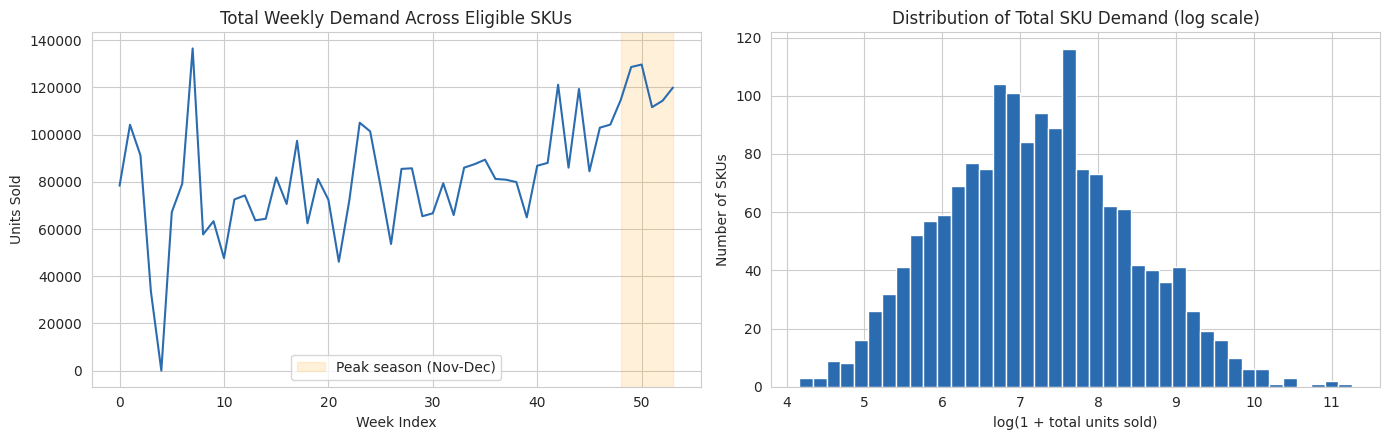

Top 5 SKUs by total volume:
StockCode
23166     78033.0
22197     56921.0
84077     55047.0
85099B    48474.0
85123A    37660.0
Name: DemandQty, dtype: float64


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))

total_weekly = panel.groupby('WeekIndex')['DemandQty'].sum()
axes[0].plot(total_weekly.index, total_weekly.values, color='#2b6cb0')
axes[0].set_title('Total Weekly Demand Across Eligible SKUs')
axes[0].set_xlabel('Week Index')
axes[0].set_ylabel('Units Sold')
axes[0].axvspan(48, 53, color='orange', alpha=0.15, label='Peak season (Nov-Dec)')
axes[0].legend()

sku_totals = panel.groupby('StockCode')['DemandQty'].sum().sort_values(ascending=False)
axes[1].hist(np.log1p(panel.groupby('StockCode')['DemandQty'].sum()), bins=40, color='#2b6cb0')
axes[1].set_title('Distribution of Total SKU Demand (log scale)')
axes[1].set_xlabel('log(1 + total units sold)')
axes[1].set_ylabel('Number of SKUs')

plt.tight_layout()
plt.show()

print("Top 5 SKUs by total volume:")
print(sku_totals.head())

## 7. Demand Shock Labelling

Because the dataset does not include an explicit shock or event calendar, demand shocks are operationally defined through statistical deviation from a rolling baseline, computed independently for each SKU's weekly demand series, using only **prior** weeks to avoid data leakage:

**4-week trailing moving average:**  $\hat{\mu}_t = \frac{1}{4}\sum_{i=1}^{4} y_{t-i}$

**4-week trailing standard deviation:**  $\hat{\sigma}_t = \mathrm{std}(y_{t-1}, ..., y_{t-4})$

**Deviation (z-) score:**  $Z_t = \dfrac{y_t - \hat{\mu}_t}{\hat{\sigma}_t}$

| z-score range | Shock severity class |
|---|---|
| z < 1.0 | Normal |
| 1.0 ≤ z < 2.0 | Moderate |
| 2.0 ≤ z < 3.0 | High |
| z ≥ 3.0 | Severe |

The framework focuses primarily on upside deviations (positive z-scores), as these drive stockout risk. The UCI Online Retail dataset carries no promotion or markdown field, so seasonality is captured through cyclical week-of-year features (`week_sin`, `week_cos`) rather than an explicit promotion or peak-season flag.

In [9]:
panel = panel.sort_values(['StockCode', 'WeekIndex']).reset_index(drop=True)
g = panel.groupby('StockCode')['DemandQty']

# Rolling trailing mean/std using only prior weeks (shift before rolling => no leakage)
panel['roll_mean_4'] = g.transform(lambda s: s.shift(1).rolling(window=4, min_periods=4).mean())
panel['roll_std_4']  = g.transform(lambda s: s.shift(1).rolling(window=4, min_periods=4).std())

panel['z_score'] = (panel['DemandQty'] - panel['roll_mean_4']) / panel['roll_std_4'].replace(0, np.nan)
panel['z_score'] = panel['z_score'].fillna(0)

def label_shock(z):
    if pd.isna(z):
        return np.nan
    if z < 1.0:
        return 0   # Normal
    elif z < 2.0:
        return 1   # Moderate
    elif z < 3.0:
        return 2   # High
    else:
        return 3   # Severe

CLASS_NAMES = {0: 'Normal', 1: 'Moderate', 2: 'High', 3: 'Severe'}
panel['shock_class'] = panel['z_score'].apply(label_shock)
panel['shock_label'] = panel['shock_class'].map(CLASS_NAMES)

# is_peak_season flag (November - December)
panel['week_start_date'] = start_date + pd.to_timedelta(panel['WeekIndex'] * 7, unit='D')
panel['month'] = panel['week_start_date'].dt.month
panel['is_peak_season'] = panel['month'].isin([11, 12]).astype(int)

# Calculate week_of_year before using it in week_sin and week_cos
panel['week_of_year'] = panel['week_start_date'].dt.isocalendar().week.astype(int)
panel['week_sin'] = np.sin(2 * np.pi * panel['week_of_year'] / 52)
panel['week_cos'] = np.cos(2 * np.pi * panel['week_of_year'] / 52)

# Lag features for model input
for lag in [1, 2, 3, 4]:
    panel[f'lag_{lag}'] = g.transform(lambda s, lag=lag: s.shift(lag))

# Drop rows without complete rolling history (first 4 weeks per SKU)
model_df = panel.dropna(subset=['roll_mean_4', 'roll_std_4', 'lag_4']).copy()
print(f"Model-ready rows: {model_df.shape}")
model_df['shock_label'].value_counts()

Model-ready rows: (81800, 18)


,count
shock_label,
Normal,63972
Severe,7990
Moderate,6632
High,3206


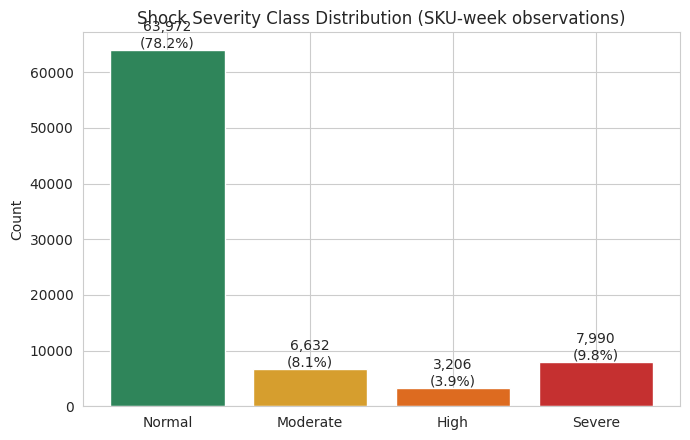

In [10]:
fig, ax = plt.subplots(figsize=(7, 4.5))
order = ['Normal', 'Moderate', 'High', 'Severe']
counts = model_df['shock_label'].value_counts().reindex(order)
colors = ['#2f855a', '#d69e2e', '#dd6b20', '#c53030']
ax.bar(counts.index, counts.values, color=colors)
ax.set_title('Shock Severity Class Distribution (SKU-week observations)')
ax.set_ylabel('Count')
for i, v in enumerate(counts.values):
    ax.text(i, v + 500, f"{v:,}\n({v/counts.sum():.1%})", ha='center')
plt.tight_layout()
plt.show()

## 8. Train / Test Split

A **chronological (time-based)** split is used to avoid look-ahead bias: the first 80% of weeks form the training set, the final ~20% (holdout) form the test set. Hyperparameter tuning within the training set uses `TimeSeriesSplit`based cross-validation,so no future information leaks into model selection. (nested time-series cross-validation), so no future information leaks into model selection.

In [11]:
FEATURE_COLS = ['roll_mean_4', 'roll_std_4', 'lag_1', 'lag_2', 'lag_3', 'lag_4',
                'week_sin', 'week_cos']
TARGET_COL = 'shock_class'

X = model_df[FEATURE_COLS]
y = model_df[TARGET_COL].astype(int)

split_week = model_df['WeekIndex'].quantile(0.8)
train_mask = model_df['WeekIndex'] <= split_week

X_train, X_test = X[train_mask], X[~train_mask]
y_train, y_test = y[train_mask], y[~train_mask]

print(f"Split at week {split_week:.0f} of {N_WEEKS}")
print(f"Train: {X_train.shape[0]:,} rows | Test: {X_test.shape[0]:,} rows")

tscv = TimeSeriesSplit(n_splits=4)

Split at week 43 of 54
Train: 65,440 rows | Test: 16,360 rows


In [12]:
model_df.loc[~train_mask].groupby('WeekIndex')['shock_class'].value_counts().unstack(fill_value=0)

shock_class,0,1,2,3
WeekIndex,,,,
44,1230,136,77,193
45,1292,140,62,142
46,1229,150,72,185
47,1320,123,55,138
48,1208,168,90,170
49,1143,191,97,205
50,1198,190,69,179
51,1259,157,74,146
52,1299,133,69,135


## 9. Export Processed Modelling Dataset

The SKU-week panel after all cleaning, aggregation, feature engineering and shock labelling (Sections 4-8) — i.e. the exact rows and columns used to fit and evaluate the classifiers below — is exported to CSV, with an explicit `split` column marking each row as `train` or `test` according to the chronological split above. This is the dataset referenced in the Methodology chapter as the model-ready SKU-week panel.

In [13]:
export_cols = ['StockCode', 'WeekIndex', 'week_start_date', 'DemandQty'] + FEATURE_COLS + \
    [TARGET_COL, 'shock_label']

processed_dataset = model_df[export_cols].copy()
processed_dataset['split'] = np.where(train_mask, 'train', 'test')

EXPORT_DIR = '/content/'  # change if running outside Colab
processed_dataset.to_csv(f'{EXPORT_DIR}processed_modelling_dataset.csv', index=False)
processed_dataset[processed_dataset['split'] == 'train'].to_csv(f'{EXPORT_DIR}train_set.csv', index=False)
processed_dataset[processed_dataset['split'] == 'test'].to_csv(f'{EXPORT_DIR}test_set.csv', index=False)

print(f"Exported {len(processed_dataset):,} rows "
      f"({(processed_dataset['split']=='train').sum():,} train / "
      f"{(processed_dataset['split']=='test').sum():,} test) "
      f"to {EXPORT_DIR}processed_modelling_dataset.csv")
processed_dataset.head()


Exported 81,800 rows (65,440 train / 16,360 test) to /content/processed_modelling_dataset.csv


,StockCode,WeekIndex,week_start_date,DemandQty,roll_mean_4,roll_std_4,lag_1,lag_2,lag_3,lag_4,week_sin,week_cos,shock_class,shock_label,split
4,10125,4,2010-12-27,0.0,38.50,46.104953,7.0,102.0,43.0,2.0,6.432491e-16,1.000000,0,Normal,train
5,10125,5,2011-01-03,98.0,38.00,46.640469,0.0,7.0,102.0,43.0,1.205367e-01,0.992709,1,Moderate,train
6,10125,6,2011-01-10,79.0,51.75,55.811438,98.0,0.0,7.0,102.0,2.393157e-01,0.970942,0,Normal,train
7,10125,7,2011-01-17,36.0,46.00,49.766120,79.0,98.0,0.0,7.0,3.546049e-01,0.935016,0,Normal,train
8,10125,8,2011-01-24,0.0,53.25,43.964948,36.0,79.0,98.0,0.0,4.647232e-01,0.885456,0,Normal,train


## 10. Model Development: Random Forest vs XGBoost vs LightGBM

To ensure XGBoost and LightGBM receive the same class-imbalance treatment as Random Forest (which uses `class_weight='balanced'`), balanced sample weights are computed from the training-set class frequencies and passed to all three models' `.fit()` calls. Without this, gradient-boosted models trained on this imbalanced label distribution collapse toward predicting the majority (Normal) class almost exclusively, which was found to bias the cross-model comparison below.

In [14]:
from sklearn.utils.class_weight import compute_sample_weight

sample_weight_train = compute_sample_weight('balanced', y_train)


In [15]:
results = {}
fitted_models = {}
predictions = {}

# --- Random Forest ---
rf_grid = {'n_estimators': [200], 'max_depth': [6, 10], 'min_samples_leaf': [5, 10]}
rf = GridSearchCV(
    RandomForestClassifier(random_state=RANDOM_STATE, class_weight='balanced'),
    rf_grid, cv=tscv, scoring='f1_macro', n_jobs=-1)
rf.fit(X_train, y_train)  # class_weight='balanced' already set on the estimator
pred = rf.predict(X_test)
p, r, f, _ = precision_recall_fscore_support(y_test, pred, average='macro', zero_division=0)
acc = accuracy_score(y_test, pred)
wf1 = f1_score(y_test, pred, average='weighted', zero_division=0)
results['RandomForest'] = {'accuracy': acc, 'precision': p, 'recall': r, 'f1': f,
                           'weighted_f1': wf1, 'best_params': rf.best_params_}
fitted_models['RandomForest'] = rf.best_estimator_
predictions['RandomForest'] = pred
print('Random Forest:', results['RandomForest'])

Random Forest: {'accuracy': 0.39138141809290955, 'precision': 0.31251946499479655, 'recall': 0.35161730353702825, 'f1': 0.2718591457952583, 'weighted_f1': 0.4666514447678995, 'best_params': {'max_depth': 10, 'min_samples_leaf': 5, 'n_estimators': 200}}


In [16]:
# --- XGBoost ---
xgb_grid = {'n_estimators': [200], 'max_depth': [4, 6], 'learning_rate': [0.1]}
xgbc = GridSearchCV(
    xgb.XGBClassifier(random_state=RANDOM_STATE, eval_metric='mlogloss'),
    xgb_grid, cv=tscv, scoring='f1_macro', n_jobs=-1)
xgbc.fit(X_train, y_train, sample_weight=sample_weight_train)
pred = xgbc.predict(X_test)
p, r, f, _ = precision_recall_fscore_support(y_test, pred, average='macro', zero_division=0)
acc = accuracy_score(y_test, pred)
wf1 = f1_score(y_test, pred, average='weighted', zero_division=0)
results['XGBoost'] = {'accuracy': acc, 'precision': p, 'recall': r, 'f1': f,
                      'weighted_f1': wf1, 'best_params': xgbc.best_params_}
fitted_models['XGBoost'] = xgbc.best_estimator_
predictions['XGBoost'] = pred
print('XGBoost:', results['XGBoost'])

XGBoost: {'accuracy': 0.3582518337408313, 'precision': 0.3080436255950234, 'recall': 0.34334128559887295, 'f1': 0.2579610439208627, 'weighted_f1': 0.4321262100034656, 'best_params': {'learning_rate': 0.1, 'max_depth': 6, 'n_estimators': 200}}


In [17]:
# --- LightGBM ---
lgb_grid = {'n_estimators': [200], 'max_depth': [4, 6], 'learning_rate': [0.1]}
lgbc = GridSearchCV(
    lgb.LGBMClassifier(random_state=RANDOM_STATE, verbose=-1),
    lgb_grid, cv=tscv, scoring='f1_macro', n_jobs=-1)
lgbc.fit(X_train, y_train, sample_weight=sample_weight_train)
pred = lgbc.predict(X_test)
p, r, f, _ = precision_recall_fscore_support(y_test, pred, average='macro', zero_division=0)
acc = accuracy_score(y_test, pred)
wf1 = f1_score(y_test, pred, average='weighted', zero_division=0)
results['LightGBM'] = {'accuracy': acc, 'precision': p, 'recall': r, 'f1': f,
                       'weighted_f1': wf1, 'best_params': lgbc.best_params_}
fitted_models['LightGBM'] = lgbc.best_estimator_
predictions['LightGBM'] = pred
print('LightGBM:', results['LightGBM'])

LightGBM: {'accuracy': 0.3428484107579462, 'precision': 0.3100705075951595, 'recall': 0.34153483404529694, 'f1': 0.2523356955788474, 'weighted_f1': 0.4166981432560784, 'best_params': {'learning_rate': 0.1, 'max_depth': 6, 'n_estimators': 200}}


In [18]:
# Full comparison table incl. accuracy and weighted F1 (Table 4.7 source)
comparison = pd.DataFrame(results).T[['accuracy', 'precision', 'recall', 'f1', 'weighted_f1']]
comparison.columns = ['Accuracy', 'Macro Precision', 'Macro Recall', 'Macro F1', 'Weighted F1']
comparison = comparison.astype(float).round(3)
comparison = comparison.sort_values('Macro F1', ascending=False)
print(comparison.to_string())
comparison

              Accuracy  Macro Precision  Macro Recall  Macro F1  Weighted F1
RandomForest     0.391            0.313         0.352     0.272        0.467
XGBoost          0.358            0.308         0.343     0.258        0.432
LightGBM         0.343            0.310         0.342     0.252        0.417


,Accuracy,Macro Precision,Macro Recall,Macro F1,Weighted F1
RandomForest,0.391,0.313,0.352,0.272,0.467
XGBoost,0.358,0.308,0.343,0.258,0.432
LightGBM,0.343,0.310,0.342,0.252,0.417


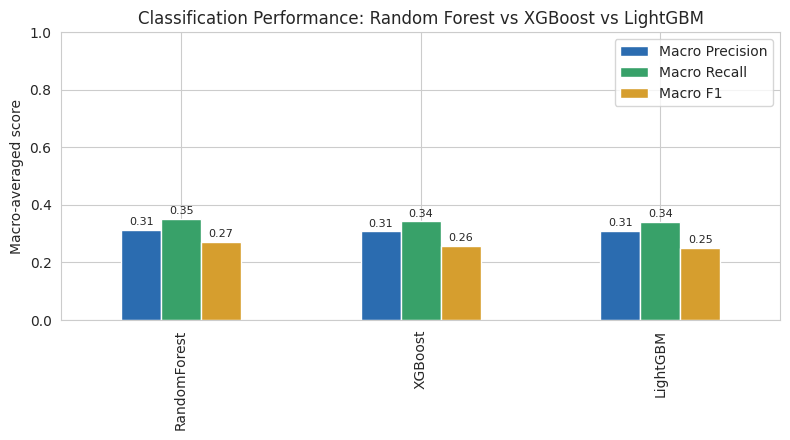

In [19]:
fig, ax = plt.subplots(figsize=(8, 4.5))
comparison[['Macro Precision', 'Macro Recall', 'Macro F1']].plot(kind='bar', ax=ax,
    color=['#2b6cb0', '#38a169', '#d69e2e'])
# Add data labels on top of each bar
for container in ax.containers:
    ax.bar_label(container, fmt='%.2f', padding=2, fontsize=8)
ax.set_title('Classification Performance: Random Forest vs XGBoost vs LightGBM')
ax.set_ylabel('Macro-averaged score')
ax.set_ylim(0, 1)
ax.legend(loc='upper right')
plt.tight_layout()
plt.show()


In [20]:
comparison.to_csv('model_comparison.csv')

## 11. Confusion Matrix Comparison Across Models

To compare where each classifier's errors concentrate across the four ordinal severity classes, the confusion matrices for all three models are plotted side by side as heatmaps, using a shared colour scale for direct visual comparison.

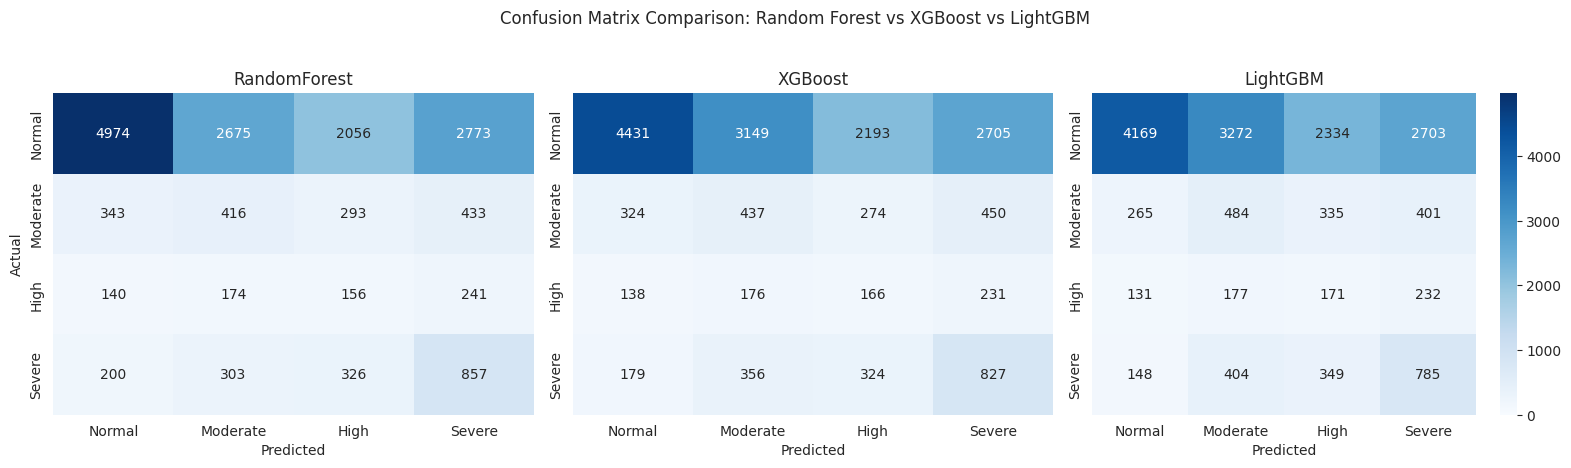

In [21]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

model_order = ['RandomForest', 'XGBoost', 'LightGBM']
vmax = max(confusion_matrix(y_test, predictions[m]).max() for m in model_order)

for ax, model_name in zip(axes, model_order):
    cm = confusion_matrix(y_test, predictions[model_name])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', vmin=0, vmax=vmax,
                xticklabels=list(CLASS_NAMES.values()), yticklabels=list(CLASS_NAMES.values()),
                cbar=(model_name == model_order[-1]), ax=ax)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual' if model_name == model_order[0] else '')
    ax.set_title(model_name)

fig.suptitle('Confusion Matrix Comparison: Random Forest vs XGBoost vs LightGBM', y=1.03)
plt.tight_layout()
plt.show()


In [22]:
cm_rows = []
for model_name in model_order:
    cm = confusion_matrix(y_test, predictions[model_name])
    class_labels = list(CLASS_NAMES.values())
    for i, actual in enumerate(class_labels):
        for j, predicted in enumerate(class_labels):
            cm_rows.append({
                'Model': model_name,
                'Actual': actual,
                'Predicted': predicted,
                'Count': int(cm[i, j])
            })

cm_df = pd.DataFrame(cm_rows)
cm_df.to_csv('confusion_matrices.csv', index=False)

## 12. Per-Class Report — All Three Models (Table 4.6 source)

Chapter 4's per-class precision/recall/F1/support table (Table 4.6) compares all three classifiers, not only the eventual best model. Previously only the best model's classification_report was generated; this cell produces the same report for Random Forest, XGBoost and LightGBM so every number in that table traces back to actual pipeline output.

In [23]:
per_class_rows = []
for model_name in ['RandomForest', 'XGBoost', 'LightGBM']:
    report = classification_report(
        y_test, predictions[model_name],
        target_names=[CLASS_NAMES[c] for c in sorted(CLASS_NAMES)],
        output_dict=True, zero_division=0
    )
    for cls in ['High', 'Moderate', 'Normal', 'Severe']:
        per_class_rows.append({
            'Model': model_name,
            'Class': cls,
            'Precision': round(report[cls]['precision'], 3),
            'Recall': round(report[cls]['recall'], 3),
            'F1-score': round(report[cls]['f1-score'], 3),
            'Support': int(report[cls]['support']),
        })

per_class_df = pd.DataFrame(per_class_rows)
print(per_class_df.to_string(index=False))
per_class_df

       Model    Class  Precision  Recall  F1-score  Support
RandomForest     High      0.055   0.219     0.088      711
RandomForest Moderate      0.117   0.280     0.165     1485
RandomForest   Normal      0.879   0.399     0.549    12478
RandomForest   Severe      0.199   0.508     0.286     1686
     XGBoost     High      0.056   0.233     0.091      711
     XGBoost Moderate      0.106   0.294     0.156     1485
     XGBoost   Normal      0.874   0.355     0.505    12478
     XGBoost   Severe      0.196   0.491     0.280     1686
    LightGBM     High      0.054   0.241     0.088      711
    LightGBM Moderate      0.112   0.326     0.166     1485
    LightGBM   Normal      0.885   0.334     0.485    12478
    LightGBM   Severe      0.190   0.466     0.270     1686


,Model,Class,Precision,Recall,F1-score,Support
0,RandomForest,High,0.055,0.219,0.088,711
1,RandomForest,Moderate,0.117,0.280,0.165,1485
2,RandomForest,Normal,0.879,0.399,0.549,12478
3,RandomForest,Severe,0.199,0.508,0.286,1686
4,XGBoost,High,0.056,0.233,0.091,711
5,XGBoost,Moderate,0.106,0.294,0.156,1485
6,XGBoost,Normal,0.874,0.355,0.505,12478
7,XGBoost,Severe,0.196,0.491,0.280,1686
8,LightGBM,High,0.054,0.241,0.088,711
9,LightGBM,Moderate,0.112,0.326,0.166,1485


In [24]:
per_class_df.to_csv('per_class_report.csv', index=False)

## 13. Best Model Selection

With the full three-model comparison complete — macro-averaged precision/recall/F1 (above) and the per-class confusion matrices (below) — the best-performing classifier is now selected by macro-F1 on the holdout set, for use in the downstream adaptive replenishment simulation.

In [25]:
BEST_MODEL_NAME = comparison['Macro F1'].idxmax()
print(f"Best model by macro-F1 on the holdout set: {BEST_MODEL_NAME}")


Best model by macro-F1 on the holdout set: RandomForest


In [26]:
test_export = model_df.loc[~train_mask, ['StockCode', 'WeekIndex', 'week_start_date']].copy()
test_export['predicted_class'] = predictions[BEST_MODEL_NAME]
test_export.to_csv('test_predictions.csv', index=False)

## 14. Random Forest Feature Importance using "Gini"

roll_std_4     0.289956
roll_mean_4    0.193486
week_cos       0.122569
lag_1          0.092291
lag_4          0.081223
lag_3          0.079728
lag_2          0.078357
week_sin       0.062389
dtype: float64


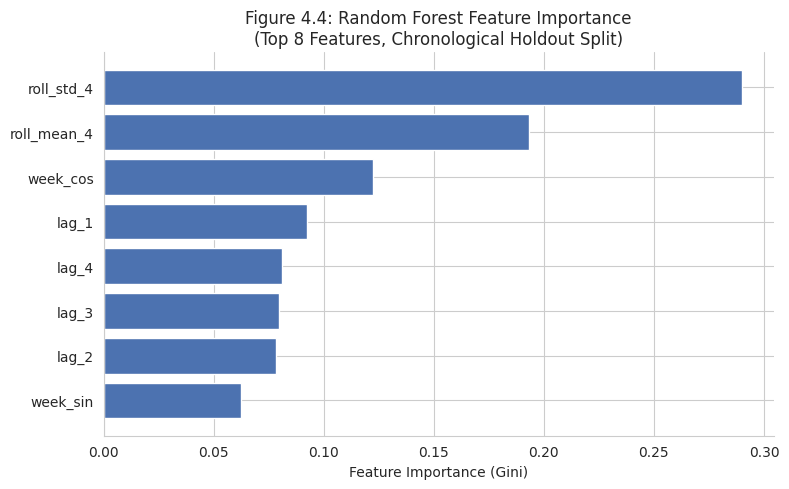


Top 3 features account for 60.6% of total importance:
  roll_std_4: 29.0%
  roll_mean_4: 19.3%
  week_cos: 12.3%


In [27]:
import pandas as pd
import matplotlib.pyplot as plt

# --- Feature importance from the final Random Forest model ---
# Use whichever variable holds your fitted Random Forest.
# If it came from GridSearchCV, use the refit best estimator:
rf_model = fitted_models[BEST_MODEL_NAME]
# Adjust the two lines below if your variable names differ.

feature_names = X_train.columns  # the columns used to fit the model
importances = pd.Series(rf_model.feature_importances_, index=feature_names)
importances = importances.sort_values(ascending=False)

# Print for the write-up / to copy numbers into prose
print(importances)

# Save the full table (useful if you want an appendix table too)
importances.to_csv('feature_importances_rf.csv', header=['importance'])

# --- Bar chart: top 10 features ---
top_n = 10
top_importances = importances.head(top_n).sort_values()  # ascending for horizontal bar

fig, ax = plt.subplots(figsize=(8, 5))
ax.barh(top_importances.index, top_importances.values, color='#4C72B0')
ax.set_xlabel('Feature Importance (Gini)')
ax.set_title('Figure 4.4: Random Forest Feature Importance\n(Top 8 Features, Chronological Holdout Split)')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()

plt.savefig('figure_4x_feature_importance.png', dpi=300, bbox_inches='tight')
plt.show()

# --- Quick stats to help you write the prose ---
top3 = importances.head(3)
print(f"\nTop 3 features account for {top3.sum():.1%} of total importance:")
for feat, val in top3.items():
    print(f"  {feat}: {val:.1%}")

## 15. Adaptive Replenishment Policy

The predicted shock severity is mapped to a replenishment action according to the following rule set, which constitutes the primary methodological contribution of this study:

| Predicted Shock Level | Replenishment Action |
|---|---|
| Normal | Standard reorder quantity (baseline reorder-point policy) |
| Moderate | Increase safety stock by 20% |
| High | Increase safety stock by 40% |
| Severe | Increase order-up-to level by 60% |

**Assumptions:** 1-week lead time; base service level ≈ 95% (z = 1.65); holding cost = £0.05/unit/week; ordering cost = £20/order; stockout penalty = £2/unit short. These are illustrative parameters standard in (s,S) inventory modelling, chosen because the dataset provides no cost fields.

In [28]:
LEAD_TIME_WEEKS = 1
SERVICE_Z = 1.65
HOLDING_COST_PER_UNIT_WEEK = 0.05
ORDER_COST = 20.0
STOCKOUT_PENALTY_PER_UNIT = 2.0

def simulate_policy(sku_df, adaptive: bool):
    """Simulate a single SKU's inventory trajectory over the holdout weeks
    under either the adaptive (ML-driven) or static (s,S) policy."""
    sku_df = sku_df.sort_values('WeekIndex')
    inv_position = sku_df['roll_mean_4'].iloc[0] * 2  # starting stock

    total_holding = total_ordering = total_stockout_cost = 0.0
    weeks_full_service = n_weeks = n_orders = 0

    for _, row in sku_df.iterrows():
        mu = row['roll_mean_4']
        sigma = row['roll_std_4'] if row['roll_std_4'] > 0 else mu * 0.3
        safety_stock = SERVICE_Z * sigma * np.sqrt(LEAD_TIME_WEEKS)

        if adaptive:
            sev = row['pred_class']
            if sev == 1:
                safety_stock *= 1.20
            elif sev == 2:
                safety_stock *= 1.40

        s = mu * LEAD_TIME_WEEKS + safety_stock
        S = s + mu * 4
        if adaptive and row['pred_class'] == 3:
            S *= 1.60

        if inv_position < s:
            order_qty = max(S - inv_position, 0)
            inv_position += order_qty
            total_ordering += ORDER_COST
            n_orders += 1

        demand = row['DemandQty']
        if inv_position >= demand:
            inv_position -= demand
            weeks_full_service += 1
        else:
            total_stockout_cost += (demand - inv_position) * STOCKOUT_PENALTY_PER_UNIT
            inv_position = 0

        total_holding += inv_position * HOLDING_COST_PER_UNIT_WEEK
        n_weeks += 1

    service_level = weeks_full_service / n_weeks
    return {
        'service_level': service_level,
        'stockout_rate': 1 - service_level,
        'ordering_cost': total_ordering,
        'holding_cost': total_holding,
        'stockout_cost': total_stockout_cost,
        'total_cost': total_holding + total_ordering + total_stockout_cost,
        'n_orders': n_orders,
    }

In [29]:
#Best-model predictions was attached to the holdout panel for simulation
sim_df = model_df.loc[~train_mask, ['StockCode', 'WeekIndex', 'DemandQty',
                                     'roll_mean_4', 'roll_std_4']].copy()
sim_df['pred_class'] = predictions[BEST_MODEL_NAME]
sim_df['true_class'] = y_test.values

adaptive_results, static_results = [], []
for sku in sim_df['StockCode'].unique():
    sdf = sim_df[sim_df['StockCode'] == sku]
    if len(sdf) < 4:
        continue
    a = simulate_policy(sdf, adaptive=True);  a['StockCode'] = sku
    s = simulate_policy(sdf, adaptive=False); s['StockCode'] = sku
    adaptive_results.append(a)
    static_results.append(s)

adaptive_df = pd.DataFrame(adaptive_results)
static_df = pd.DataFrame(static_results)
print(f"SKUs simulated: {len(adaptive_df)}")

SKUs simulated: 1636


## 16. Inventory Performance Comparison

In [30]:
metrics = ['service_level', 'stockout_rate', 'ordering_cost', 'holding_cost', 'total_cost']
summary = pd.DataFrame({
    'Adaptive (ML-driven)': adaptive_df[metrics].mean(),
    'Static (s,S) Baseline': static_df[metrics].mean(),
})
summary['Improvement'] = summary['Adaptive (ML-driven)'] - summary['Static (s,S) Baseline']
summary['Improvement %'] = (summary['Improvement'] / summary['Static (s,S) Baseline'].abs()) * 100
summary.round(4)

# Also report totals across all simulated SKUs (Table 4.8 uses totals, not per-SKU means)
adaptive_df['stockout_cost'] = adaptive_df['total_cost'] - adaptive_df['holding_cost'] - adaptive_df['ordering_cost']
static_df['stockout_cost'] = static_df['total_cost'] - static_df['holding_cost'] - static_df['ordering_cost']

totals_metrics = ['service_level', 'stockout_rate', 'holding_cost', 'ordering_cost', 'stockout_cost', 'total_cost']
totals = pd.DataFrame({
    'Static (s,S) Baseline': [
        static_df['service_level'].mean(), static_df['stockout_rate'].mean(),
        static_df['holding_cost'].sum(), static_df['ordering_cost'].sum(),
        static_df['stockout_cost'].sum(), static_df['total_cost'].sum(),
    ],
    'Adaptive (ML-driven)': [
        adaptive_df['service_level'].mean(), adaptive_df['stockout_rate'].mean(),
        adaptive_df['holding_cost'].sum(), adaptive_df['ordering_cost'].sum(),
        adaptive_df['stockout_cost'].sum(), adaptive_df['total_cost'].sum(),
    ],
}, index=['Avg. Service Level', 'Avg. Stockout Rate', 'Total Holding Cost (£)',
          'Total Ordering Cost (£)', 'Total Stockout Cost (£)', 'Total Inventory Cost (£)'])
totals['Change'] = totals['Adaptive (ML-driven)'] - totals['Static (s,S) Baseline']
totals['Change %'] = (totals['Change'] / totals['Static (s,S) Baseline'].abs()) * 100
print(totals.round(2).to_string())
totals.round(2)

                          Static (s,S) Baseline  Adaptive (ML-driven)    Change  Change %
Avg. Service Level                         0.95                  0.96      0.01      0.88
Avg. Stockout Rate                         0.05                  0.04     -0.01    -18.49
Total Holding Cost (£)                246447.65             257249.38  10801.73      4.38
Total Ordering Cost (£)                77860.00              73840.00  -4020.00     -5.16
Total Stockout Cost (£)               135955.60             123218.69 -12736.91     -9.37
Total Inventory Cost (£)              460263.25             454308.07  -5955.18     -1.29


,"Static (s,S) Baseline",Adaptive (ML-driven),Change,Change %
Avg. Service Level,0.95,0.96,0.01,0.88
Avg. Stockout Rate,0.05,0.04,-0.01,-18.49
Total Holding Cost (£),246447.65,257249.38,10801.73,4.38
Total Ordering Cost (£),77860.00,73840.00,-4020.00,-5.16
Total Stockout Cost (£),135955.60,123218.69,-12736.91,-9.37
Total Inventory Cost (£),460263.25,454308.07,-5955.18,-1.29


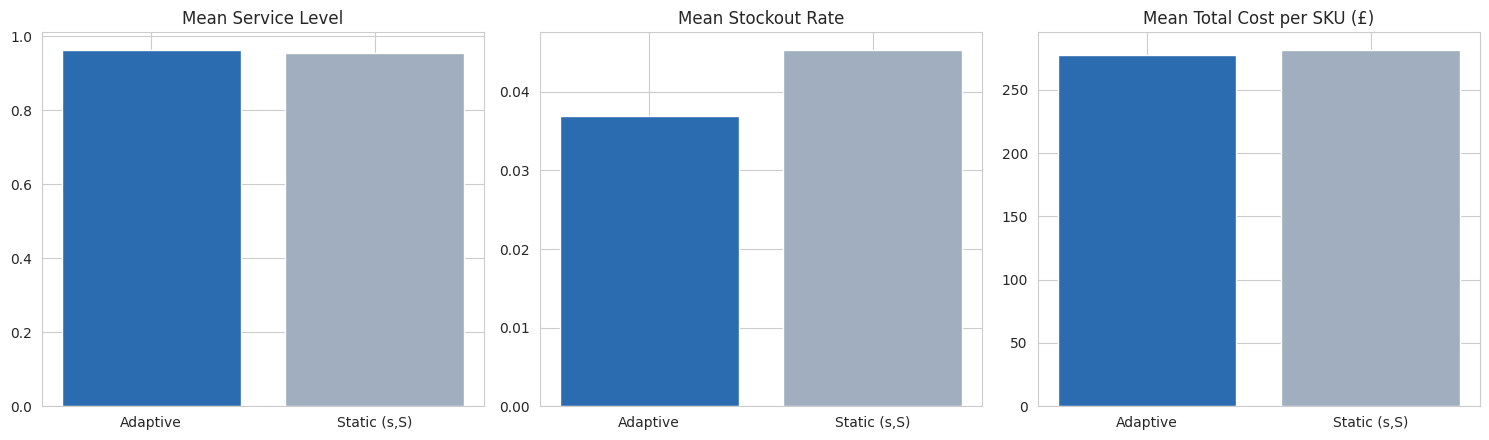

In [31]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

for ax, metric, title in zip(
    axes,
    ['service_level', 'stockout_rate', 'total_cost'],
    ['Mean Service Level', 'Mean Stockout Rate', 'Mean Total Cost per SKU (£)']
):
    vals = [adaptive_df[metric].mean(), static_df[metric].mean()]
    ax.bar(['Adaptive', 'Static (s,S)'], vals, color=['#2b6cb0', '#a0aec0'])
    ax.set_title(title)

plt.tight_layout()
plt.show()

## 17. Statistical Significance Testing

Using a **Wilcoxon signed-rank test** (paired, non-parametric) to test whether the per-SKU differences between the adaptive and static policies are statistically significant.

### 17.1 Per-SKU Saving Distribution and Bootstrap CI (Section 4.14 source)

In [32]:
rng = np.random.default_rng(RANDOM_STATE)

per_sku_saving = static_df.set_index('StockCode')['total_cost'] - adaptive_df.set_index('StockCode')['total_cost']
# positive value = adaptive saved money relative to static

pct_improved = (per_sku_saving > 0).mean() * 100
mean_saving = per_sku_saving.mean()
median_saving = per_sku_saving.median()

print(f"SKUs with a total-cost reduction under the adaptive policy: {pct_improved:.1f}% "
      f"({(per_sku_saving > 0).sum():,} of {len(per_sku_saving):,})")
print(f"Mean per-SKU saving: £{mean_saving:.2f}")
print(f"Median per-SKU saving: £{median_saving:.2f}")

# Paired bootstrap 95% CI for the mean per-SKU saving
N_BOOT = 5000
boot_means = np.empty(N_BOOT)
vals = per_sku_saving.values
n = len(vals)
for b in range(N_BOOT):
    sample = rng.choice(vals, size=n, replace=True)
    boot_means[b] = sample.mean()

ci_low, ci_high = np.percentile(boot_means, [2.5, 97.5])
print(f"\nPaired bootstrap 95% CI for mean saving ({N_BOOT} resamples): [£{ci_low:.2f}, £{ci_high:.2f}]")
print(f"{'Excludes' if ci_low > 0 or ci_high < 0 else 'Includes'} zero -> "
      f"{'statistically significant' if ci_low > 0 or ci_high < 0 else 'not statistically significant'} at the 5% level")

SKUs with a total-cost reduction under the adaptive policy: 33.7% (551 of 1,636)
Mean per-SKU saving: £3.64
Median per-SKU saving: £0.00

Paired bootstrap 95% CI for mean saving (5000 resamples): [£1.13, £6.30]
Excludes zero -> statistically significant at the 5% level


In [33]:
for metric in ['total_cost', 'service_level', 'stockout_rate']:
    stat, pval = wilcoxon(adaptive_df[metric], static_df[metric])
    direction = 'lower' if adaptive_df[metric].mean() < static_df[metric].mean() else 'higher'
    print(f"{metric:15s}: Wilcoxon stat={stat:8.2f}  p-value={pval:.4f}  "
          f"(adaptive mean is {direction} than static; "
          f"{'significant' if pval < 0.05 else 'not significant'} at α=0.05)")

total_cost     : Wilcoxon stat=369506.00  p-value=0.1241  (adaptive mean is lower than static; not significant at α=0.05)
service_level  : Wilcoxon stat= 5075.50  p-value=0.0000  (adaptive mean is higher than static; significant at α=0.05)
stockout_rate  : Wilcoxon stat= 5075.50  p-value=0.0000  (adaptive mean is lower than static; significant at α=0.05)
